In [ ]:
from pathlib import Path
import pandas as pd

#BASE_DIR = Path(r"c:\Projetos\estudo_curva")
BASE_DIR = Path.cwd()
DATA_PROCESSED_DIR = BASE_DIR / "data_processed"

candidate_files = [
    "fair_value_zscore_analysis_master.csv",
    "fair_value_zscore_backtest.csv",
    "curve_macro_stat_ready.csv",
]

chosen = None
for fname in candidate_files:
    fpath = DATA_PROCESSED_DIR / fname
    if fpath.exists():
        chosen = fpath
        break

if chosen is None:
    raise FileNotFoundError(
        f"Not founded {DATA_PROCESSED_DIR}. "
        f"file: {candidate_files}"
    )

print("file:", chosen)

df = pd.read_csv(chosen)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

Usando arquivo: c:\Projetos\estudo_curva\data_processed\fair_value_zscore_backtest.csv


In [96]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss

TARGET_COL = "spread_obs"
SIGNAL_COL = "mispricing_z"

print("TARGET_COL =", TARGET_COL)
print("SIGNAL_COL =", SIGNAL_COL)

TARGET_COL = spread_obs
SIGNAL_COL = mispricing_z


In [97]:
def safe_adf_pvalue(x: pd.Series) -> float:
    x = x.dropna()
    if len(x) < 80:
        return np.nan
    try:
        return adfuller(x, autolag="AIC")[1]
    except Exception:
        return np.nan

def safe_kpss_pvalue(x: pd.Series) -> float:
    x = x.dropna()
    if len(x) < 80:
        return np.nan
    try:
        return kpss(x, regression="c", nlags="auto")[1]
    except Exception:
        return np.nan

def trend_tstat(x: pd.Series) -> float:
    x = x.dropna()
    if len(x) < 80:
        return np.nan
    try:
        y = x.values
        t = np.arange(len(y))
        X = sm.add_constant(t)
        model = sm.OLS(y, X).fit()
        return model.tvalues[1]
    except Exception:
        return np.nan

def mean_shift_zscore(x: pd.Series, recent_window: int = 42) -> float:
    x = x.dropna()
    if len(x) < max(100, recent_window + 20):
        return np.nan

    old = x.iloc[:-recent_window]
    recent = x.iloc[-recent_window:]

    sigma = x.std()
    if pd.isna(sigma) or sigma == 0:
        return np.nan

    return (recent.mean() - old.mean()) / sigma

In [98]:
REGIME_WINDOW = 154
RECENT_WINDOW = 21
REGIME_STEP = 3

regime_rows = []

for end_ix in range(REGIME_WINDOW, len(df), REGIME_STEP):
    window_df = df.iloc[end_ix - REGIME_WINDOW:end_ix].copy()
    x = window_df[TARGET_COL]

    adf_p = safe_adf_pvalue(x)
    kpss_p = safe_kpss_pvalue(x)
    trend_t = trend_tstat(x)
    shift_z = mean_shift_zscore(x, recent_window=RECENT_WINDOW)

    if (
        pd.notna(adf_p) and pd.notna(kpss_p) and pd.notna(trend_t) and pd.notna(shift_z)
        and adf_p < 0.05
        and kpss_p > 0.05
        and abs(shift_z) < 1.0
        and abs(trend_t) < 2.0
    ):
        regime = "stationary"

    elif pd.notna(shift_z) and pd.notna(trend_t) and shift_z > 1.0 and trend_t > 2.0:
        regime = "shift_up"

    elif pd.notna(shift_z) and pd.notna(trend_t) and shift_z < -1.0 and trend_t < -2.0:
        regime = "shift_down"

    else:
        regime = "neutral"

    regime_rows.append({
        "date": df["date"].iloc[end_ix - 1],
        "adf_pvalue": adf_p,
        "kpss_pvalue": kpss_p,
        "trend_tstat": trend_t,
        "mean_shift_z": shift_z,
        "regime": regime,
    })

regime_df = pd.DataFrame(regime_rows)

df = df.merge(regime_df, on="date", how="left")
df[["adf_pvalue", "kpss_pvalue", "trend_tstat", "mean_shift_z", "regime"]] = (
    df[["adf_pvalue", "kpss_pvalue", "trend_tstat", "mean_shift_z", "regime"]].ffill()
)

print(df[["date", TARGET_COL, "regime"]].tail(20))
print(df["regime"].value_counts(dropna=False))

C:\Users\lopes\AppData\Local\Temp\ipykernel_33348\3823587353.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  return kpss(x, regression="c", nlags="auto")[1]
C:\Users\lopes\AppData\Local\Temp\ipykernel_33348\3823587353.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  return kpss(x, regression="c", nlags="auto")[1]
C:\Users\lopes\AppData\Local\Temp\ipykernel_33348\3823587353.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  return kpss(x, regression="c", nlags="auto")[1]
C:\Users\lopes\AppData\Local\Temp\ipykernel_33348\3823587353.py:15: InterpolationWarning: The test statistic is outside of the range of p-values 

           date  spread_obs    regime
3233 2026-02-04    1.788858  shift_up
3234 2026-02-05    1.850499  shift_up
3235 2026-02-06    1.973913  shift_up
3236 2026-02-09    1.878181  shift_up
3237 2026-02-10    1.803648  shift_up
3238 2026-02-11    1.916477  shift_up
3239 2026-02-12    1.890198  shift_up
3240 2026-02-13    1.810334  shift_up
3241 2026-02-18    1.777455  shift_up
3242 2026-02-19    1.873837  shift_up
3243 2026-02-20    1.910909  shift_up
3244 2026-02-23    1.951327  shift_up
3245 2026-02-24    1.917423  shift_up
3246 2026-02-25    1.814442  shift_up
3247 2026-02-26    1.861437  shift_up
3248 2026-02-27    1.639342  shift_up
3249 2026-03-02    1.634053  shift_up
3250 2026-03-03    1.570177  shift_up
3251 2026-03-04    1.536512  shift_up
3252 2026-03-05    1.594840  shift_up
regime
neutral       1302
shift_down     891
shift_up       859
NaN            153
stationary      48
Name: count, dtype: int64


C:\Users\lopes\AppData\Local\Temp\ipykernel_33348\3823587353.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(x, regression="c", nlags="auto")[1]
C:\Users\lopes\AppData\Local\Temp\ipykernel_33348\3823587353.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(x, regression="c", nlags="auto")[1]
C:\Users\lopes\AppData\Local\Temp\ipykernel_33348\3823587353.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(x, regression="c", nlags="auto")[1]
C:\Users\lopes\AppData\Local\Temp\ipykernel_33348\3823587353.py:15: InterpolationWarning: The test statistic is outside of the range of p-values 

In [99]:
ENTRY_Z = 1.50
EXIT_Z = 0.50

def build_regime_switching_position(z: pd.Series, regime: pd.Series, entry_z: float, exit_z: float) -> pd.Series:
    pos = []
    prev = 0.0

    for zval, reg in zip(z, regime):
        if pd.isna(zval) or pd.isna(reg):
            pos.append(0.0)
            prev = 0.0
            continue

        if reg == "stationary":
            # mean reversion
            if prev == 0.0:
                if zval >= entry_z:
                    prev = -1.0
                elif zval <= -entry_z:
                    prev = 1.0
                else:
                    prev = 0.0

            elif prev > 0.0:
                if zval >= entry_z:
                    prev = -1.0
                elif zval >= -exit_z:
                    prev = 0.0
                else:
                    prev = 1.0

            elif prev < 0.0:
                if zval <= -entry_z:
                    prev = 1.0
                elif zval <= exit_z:
                    prev = 0.0
                else:
                    prev = -1.0

        elif reg == "shift_up":
            prev = 1.0

        elif reg == "shift_down":
            prev = -1.0

        else:
            prev = 0.0

        pos.append(prev)

    return pd.Series(pos, index=z.index)

df["position_regime_switch"] = build_regime_switching_position(
    df[SIGNAL_COL],
    df["regime"],
    entry_z=ENTRY_Z,
    exit_z=EXIT_Z
)

print(df[["date", SIGNAL_COL, "regime", "position_regime_switch"]].tail(20))

           date  mispricing_z    regime  position_regime_switch
3233 2026-02-04     -1.314136  shift_up                     1.0
3234 2026-02-05     -1.499836  shift_up                     1.0
3235 2026-02-06     -1.606748  shift_up                     1.0
3236 2026-02-09     -1.608300  shift_up                     1.0
3237 2026-02-10     -1.260307  shift_up                     1.0
3238 2026-02-11     -2.089293  shift_up                     1.0
3239 2026-02-12     -1.580881  shift_up                     1.0
3240 2026-02-13     -1.953589  shift_up                     1.0
3241 2026-02-18     -1.345884  shift_up                     1.0
3242 2026-02-19     -2.082525  shift_up                     1.0
3243 2026-02-20     -1.513500  shift_up                     1.0
3244 2026-02-23     -2.249476  shift_up                     1.0
3245 2026-02-24     -2.167644  shift_up                     1.0
3246 2026-02-25     -1.410342  shift_up                     1.0
3247 2026-02-26     -1.374465  shift_up 

In [100]:
DV01_POSITION = 10_000
TCOST_BPS = 0.50
ANNUALIZATION = 252

df["position_lag1_regime"] = df["position_regime_switch"].shift(1).fillna(0.0)

df["gross_pnl_regime"] = (
    df["position_lag1_regime"] *
    df["spread_change_1d_bps"] *
    DV01_POSITION
)

df["turnover_regime"] = df["position_regime_switch"].diff().abs().fillna(0.0)

df["transaction_cost_regime"] = (
    df["turnover_regime"] *
    TCOST_BPS *
    DV01_POSITION
)

df["net_pnl_regime"] = df["gross_pnl_regime"] - df["transaction_cost_regime"]
df["equity_gross_regime"] = df["gross_pnl_regime"].cumsum()
df["equity_net_regime"] = df["net_pnl_regime"].cumsum()

df["running_max_regime"] = df["equity_net_regime"].cummax()
df["drawdown_regime"] = df["equity_net_regime"] - df["running_max_regime"]

In [101]:
DV01_POSITION = 10_000
TCOST_BPS = 0.50
ANNUALIZATION = 252

df["position_lag1_regime"] = df["position_regime_switch"].shift(1).fillna(0.0)

df["gross_pnl_regime"] = (
    df["position_lag1_regime"] *
    df["spread_change_1d_bps"] *
    DV01_POSITION
)

df["turnover_regime"] = df["position_regime_switch"].diff().abs().fillna(0.0)

df["transaction_cost_regime"] = (
    df["turnover_regime"] *
    TCOST_BPS *
    DV01_POSITION
)

df["net_pnl_regime"] = df["gross_pnl_regime"] - df["transaction_cost_regime"]
df["equity_gross_regime"] = df["gross_pnl_regime"].cumsum()
df["equity_net_regime"] = df["net_pnl_regime"].cumsum()

df["running_max_regime"] = df["equity_net_regime"].cummax()
df["drawdown_regime"] = df["equity_net_regime"] - df["running_max_regime"]

In [102]:
def compute_perf_metrics(backtest_df: pd.DataFrame, pnl_col: str, drawdown_col: str, position_col: str, turnover_col: str) -> dict:
    x = backtest_df[pnl_col].dropna().copy()

    if len(x) < 20:
        return {
            "nobs": len(x),
            "total_pnl": np.nan,
            "annualized_pnl": np.nan,
            "annualized_vol": np.nan,
            "sharpe": np.nan,
            "max_drawdown": np.nan,
            "avg_abs_position": np.nan,
            "annual_turnover": np.nan,
            "hit_ratio": np.nan,
        }

    mean_daily = x.mean()
    vol_daily = x.std()
    annualized_pnl = mean_daily * ANNUALIZATION
    annualized_vol = vol_daily * np.sqrt(ANNUALIZATION)
    sharpe = annualized_pnl / annualized_vol if annualized_vol > 0 else np.nan

    return {
        "nobs": len(x),
        "total_pnl": x.sum(),
        "annualized_pnl": annualized_pnl,
        "annualized_vol": annualized_vol,
        "sharpe": sharpe,
        "max_drawdown": backtest_df[drawdown_col].min(),
        "avg_abs_position": backtest_df[position_col].abs().mean(),
        "annual_turnover": backtest_df[turnover_col].sum() / (len(backtest_df) / ANNUALIZATION),
        "hit_ratio": (x > 0).mean(),
    }

metrics_old = compute_perf_metrics(
    df,
    pnl_col="net_pnl",
    drawdown_col="drawdown",
    position_col="position",
    turnover_col="turnover"
)

metrics_regime = compute_perf_metrics(
    df,
    pnl_col="net_pnl_regime",
    drawdown_col="drawdown_regime",
    position_col="position_regime_switch",
    turnover_col="turnover_regime"
)

comparison = pd.DataFrame([
    {"strategy": "fair_value_zscore", **metrics_old},
    {"strategy": "regime_switching", **metrics_regime},
])

print(comparison.T)

                                  0                 1
strategy          fair_value_zscore  regime_switching
nobs                           3252              3252
total_pnl            2250927.789821    2909927.739979
annualized_pnl        174426.138695     225492.555497
annualized_vol       1694618.476093    1658552.315384
sharpe                     0.102929          0.135957
max_drawdown         -4240165.11373   -4449412.176969
avg_abs_position           0.581002          0.528743
annual_turnover            7.824162          4.725484
hit_ratio                  0.292743          0.263838


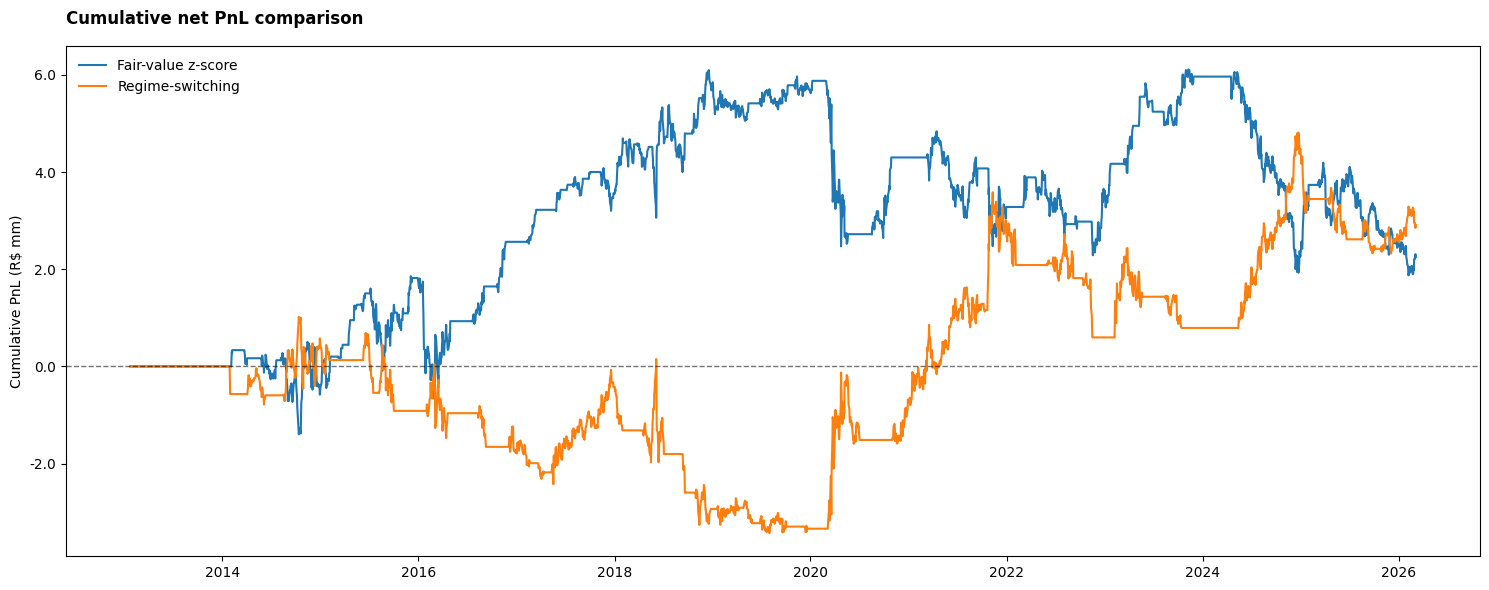

In [103]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(15, 6))

plot_df = df.dropna(subset=["equity_net", "equity_net_regime"]).copy()
ax.plot(plot_df["date"], plot_df["equity_net"] / 1e6, label="Fair-value z-score")
ax.plot(plot_df["date"], plot_df["equity_net_regime"] / 1e6, label="Regime-switching")

ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.55)
ax.set_title("Cumulative net PnL comparison", loc="left", pad=16, fontweight="bold")
ax.set_ylabel("Cumulative PnL (R$ mm)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.1f}"))

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.legend(loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

In [106]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

In [107]:
# ------------------------------------------------------------
# 0) Paths
# ------------------------------------------------------------
BASE_DIR = Path.cwd()

DATA_PROCESSED_DIR = BASE_DIR / "data_processed"
TABLES_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"
COINT_FIG_DIR = FIG_DIR / "05_cointegration"

DATA_PROCESSED_DIR.mkdir(exist_ok=True)
TABLES_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)
COINT_FIG_DIR.mkdir(exist_ok=True)

MASTER_CANDIDATES = [
    DATA_PROCESSED_DIR / "fair_value_zscore_analysis_master.csv",
    DATA_PROCESSED_DIR / "fair_value_zscore_backtest.csv",
]

FORWARD_CANDIDATES = [
    DATA_PROCESSED_DIR / "curve_forwards_252.csv",
    DATA_PROCESSED_DIR / "curve_macro_stat_ready.csv",
    DATA_PROCESSED_DIR / "curve_macro_merged.csv",
]

def first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None

master_path = first_existing(MASTER_CANDIDATES)
forward_path = first_existing(FORWARD_CANDIDATES)

if master_path is None:
    raise FileNotFoundError(
        f"Could not find any master backtest dataset in {DATA_PROCESSED_DIR}. "
        f"Tried: {[p.name for p in MASTER_CANDIDATES]}"
    )

if forward_path is None:
    raise FileNotFoundError(
        f"Could not find any forward dataset in {DATA_PROCESSED_DIR}. "
        f"Tried: {[p.name for p in FORWARD_CANDIDATES]}"
    )

print("Master dataset:", master_path)
print("Forward dataset:", forward_path)

Master dataset: c:\Projetos\estudo_curva\data_processed\fair_value_zscore_backtest.csv
Forward dataset: c:\Projetos\estudo_curva\data_processed\curve_forwards_252.csv


In [108]:
# ------------------------------------------------------------
# 1) Load datasets
# ------------------------------------------------------------
master_df = pd.read_csv(master_path)
master_df["date"] = pd.to_datetime(master_df["date"], errors="coerce")
master_df = master_df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

forward_df = pd.read_csv(forward_path)
if "date" not in forward_df.columns:
    if "data_referencia" in forward_df.columns:
        forward_df["date"] = pd.to_datetime(forward_df["data_referencia"], errors="coerce")
    else:
        raise ValueError("Forward dataset does not contain a recognizable date column.")

forward_df["date"] = pd.to_datetime(forward_df["date"], errors="coerce")
forward_df = forward_df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

print("Master columns:")
print(master_df.columns.tolist())
print("\nForward columns:")
print(forward_df.columns.tolist())

Master columns:
['date', 'spread_obs', 'fair_value', 'mispricing', 'n_train', 'mispricing_mean_roll', 'mispricing_std_roll', 'mispricing_z', 'position', 'next_date', 'calendar_days_to_next', 'rolldown_change_1d', 'spread_change_1d', 'market_move_change_1d', 'spread_change_1d_bps', 'rolldown_change_1d_bps', 'market_move_change_1d_bps', 'position_lag1', 'gross_pnl', 'carry_rolldown_pnl', 'market_move_pnl', 'turnover', 'transaction_cost', 'net_pnl', 'equity_gross', 'equity_net', 'carry_rolldown_equity', 'market_move_equity', 'running_max', 'drawdown']

Forward columns:
['date', 'dc_1y', 'dc_2y', 'dc_5y', 'dc_10y', 'z_1y', 'z_2y', 'z_5y', 'z_10y', 'fwd_1y1y', 'fwd_5y5y', 'spread_5y5y_minus_1y1y']


In [109]:
# ------------------------------------------------------------
# 2) Resolve the forward pair columns and merge
# ------------------------------------------------------------
def find_first_match(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

FWD_1Y1Y_COL = find_first_match(forward_df, ["fwd_1y1y", "1y1y"])
FWD_5Y5Y_COL = find_first_match(forward_df, ["fwd_5y5y", "5y5y"])
SPREAD_COL_MASTER = find_first_match(master_df, ["spread_obs", "spread_5y5y_minus_1y1y"])
SPREAD_COL_FORWARD = find_first_match(forward_df, ["spread_5y5y_minus_1y1y", "spread_obs"])

if FWD_1Y1Y_COL is None or FWD_5Y5Y_COL is None:
    raise ValueError(
        "Could not find forward columns in the forward dataset. "
        "Expected something like fwd_1y1y and fwd_5y5y."
    )

pair_df = forward_df[["date", FWD_1Y1Y_COL, FWD_5Y5Y_COL]].copy()
pair_df = pair_df.rename(columns={
    FWD_1Y1Y_COL: "fwd_1y1y",
    FWD_5Y5Y_COL: "fwd_5y5y",
})

if SPREAD_COL_FORWARD is not None and SPREAD_COL_FORWARD not in ["fwd_1y1y", "fwd_5y5y"]:
    pair_df["spread_from_forward_file"] = forward_df[SPREAD_COL_FORWARD]

df = master_df.merge(pair_df, on="date", how="left")

if SPREAD_COL_MASTER is not None:
    df["spread_obs"] = df[SPREAD_COL_MASTER]
elif "spread_from_forward_file" in df.columns:
    df["spread_obs"] = df["spread_from_forward_file"]
else:
    df["spread_obs"] = df["fwd_5y5y"] - df["fwd_1y1y"]

for col in ["fwd_1y1y", "fwd_5y5y", "spread_obs"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.sort_values("date").reset_index(drop=True)

print(df[["date", "fwd_1y1y", "fwd_5y5y", "spread_obs"]].head())
print(df[["date", "fwd_1y1y", "fwd_5y5y", "spread_obs"]].tail())

        date  fwd_1y1y   fwd_5y5y  spread_obs
0 2013-01-22  8.636015  10.310209    2.226090
1 2013-01-23  8.610004  10.280486    2.215403
2 2013-01-24  8.726687  10.359836    2.145594
3 2013-01-28  8.704570  10.379229    2.237532
4 2013-01-29  8.611293  10.347104    2.267235
           date   fwd_1y1y   fwd_5y5y  spread_obs
3248 2026-02-27  12.104008  13.608547    1.639342
3249 2026-03-02  12.236164  13.667768    1.634053
3250 2026-03-03  12.456104  13.787350    1.570177
3251 2026-03-04  12.348668  13.687159    1.536512
3252 2026-03-05  12.630280  13.912669    1.594840


In [110]:
# ------------------------------------------------------------
# 3) Plot style and helpers
# ------------------------------------------------------------
plt.rcParams.update({
    "figure.figsize": (15, 6),
    "axes.titlesize": 17,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.18,
    "grid.linestyle": "--",
    "lines.linewidth": 2.0,
    "savefig.dpi": 300,
})

def pct_formatter(x, pos):
    return f"{x:.1f}%"

def setup_time_axis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.set_xlabel("")

def add_subtitle(ax, subtitle: str):
    ax.text(
        0.0, 1.02, subtitle,
        transform=ax.transAxes,
        fontsize=11,
        alpha=0.80
    )

def save_table(
    df_table: pd.DataFrame,
    filename_stem: str,
    index: bool = False,
    rename_map: dict | None = None,
    value_maps: dict | None = None,
    float_fmt: str = "%.4f",
):
    csv_path = TABLES_DIR / f"{filename_stem}.csv"
    tex_path = TABLES_DIR / f"{filename_stem}.tex"

    out_csv = df_table.copy()
    out_csv.to_csv(csv_path, index=index)

    out_tex = df_table.copy()

    if value_maps:
        for col, mapper in value_maps.items():
            if col in out_tex.columns:
                out_tex[col] = out_tex[col].replace(mapper)

    if rename_map:
        out_tex = out_tex.rename(columns=rename_map)

    latex_str = out_tex.to_latex(
        index=index,
        escape=True,
        float_format=float_fmt,
        na_rep=""
    )
    tex_path.write_text(latex_str, encoding="utf-8")

    print("Saved:", csv_path)
    print("Saved:", tex_path)

## Rolling Engle-Granger setup


In [111]:
# ------------------------------------------------------------
# 4) Rolling cointegration functions
# ------------------------------------------------------------
def estimate_half_life(resid: pd.Series) -> float:
    resid = pd.Series(resid).dropna()
    if len(resid) < 30:
        return np.nan

    lag = resid.shift(1).dropna()
    delta = resid.diff().dropna()

    aligned = pd.concat([delta, lag], axis=1).dropna()
    if len(aligned) < 30:
        return np.nan

    aligned.columns = ["delta", "lag"]

    try:
        X = sm.add_constant(aligned["lag"])
        model = sm.OLS(aligned["delta"], X).fit()
        phi = model.params["lag"]

        if pd.isna(phi) or phi >= 0:
            return np.nan

        return -np.log(2) / phi
    except Exception:
        return np.nan

def rolling_cointegration(df_in, x_col, y_col, date_col="date", window=252, step=5):
    rows = []

    tmp = df_in[[date_col, x_col, y_col]].dropna().copy().reset_index(drop=True)

    for end_ix in range(window, len(tmp) + 1, step):
        win = tmp.iloc[end_ix - window:end_ix].copy()

        x = win[x_col]
        y = win[y_col]

        try:
            coint_stat, pvalue, _ = coint(y, x)

            X = sm.add_constant(x)
            model = sm.OLS(y, X).fit()
            alpha = model.params["const"]
            beta = model.params[x_col]
            resid = model.resid

            resid_std = resid.std()
            half_life = estimate_half_life(resid)

        except Exception:
            coint_stat = np.nan
            pvalue = np.nan
            alpha = np.nan
            beta = np.nan
            resid_std = np.nan
            half_life = np.nan

        rows.append({
            "date": win[date_col].iloc[-1],
            "coint_stat": coint_stat,
            "pvalue_coint": pvalue,
            "alpha": alpha,
            "beta": beta,
            "resid_std": resid_std,
            "half_life_days": half_life,
        })

    return pd.DataFrame(rows)

def classify_cointegration_regime(p):
    if pd.isna(p):
        return np.nan
    if p < 0.01:
        return "strong"
    if p < 0.05:
        return "moderate"
    if p < 0.10:
        return "weak"
    return "none"

In [112]:
# ------------------------------------------------------------
# 5) Run rolling cointegration
# ------------------------------------------------------------
COINT_WINDOW = 252
COINT_STEP = 5

coint_df = rolling_cointegration(
    df,
    x_col="fwd_1y1y",
    y_col="fwd_5y5y",
    date_col="date",
    window=COINT_WINDOW,
    step=COINT_STEP
)

coint_df["cointegration_regime"] = coint_df["pvalue_coint"].apply(classify_cointegration_regime)
coint_df["cointegrated_5pct"] = coint_df["pvalue_coint"] < 0.05
coint_df["cointegrated_5pct_smooth"] = (
    coint_df["cointegrated_5pct"]
    .rolling(3, min_periods=1)
    .mean() >= (2 / 3)
)

print(coint_df.head())
print(coint_df.tail())
print(coint_df["cointegration_regime"].value_counts(dropna=False))

        date  coint_stat  pvalue_coint     alpha      beta  resid_std  \
0 2014-01-27   -2.509076      0.275081  3.344446  0.769920   0.291622   
1 2014-02-03   -2.845377      0.151673  3.215542  0.781495   0.289288   
2 2014-02-10   -2.808563      0.162975  3.090926  0.792427   0.284823   
3 2014-02-17   -2.714901      0.194265  2.979615  0.802010   0.280200   
4 2014-02-24   -2.598290      0.237520  2.918590  0.807985   0.283991   

   half_life_days cointegration_regime  cointegrated_5pct  \
0       13.969421                 none              False   
1       11.961815                 none              False   
2       11.941599                 none              False   
3       12.115842                 none              False   
4       12.811312                 none              False   

   cointegrated_5pct_smooth  
0                     False  
1                     False  
2                     False  
3                     False  
4                     False  
          date

In [113]:
# ------------------------------------------------------------
# 6) Merge rolling cointegration back into daily dataset
# ------------------------------------------------------------
df = df.merge(
    coint_df[[
        "date",
        "pvalue_coint",
        "coint_stat",
        "alpha",
        "beta",
        "resid_std",
        "half_life_days",
        "cointegration_regime",
        "cointegrated_5pct",
        "cointegrated_5pct_smooth",
    ]],
    on="date",
    how="left"
)

fill_cols = [
    "pvalue_coint",
    "coint_stat",
    "alpha",
    "beta",
    "resid_std",
    "half_life_days",
    "cointegration_regime",
    "cointegrated_5pct",
    "cointegrated_5pct_smooth",
]
df[fill_cols] = df[fill_cols].ffill()

print(df[["date", "fwd_1y1y", "fwd_5y5y", "pvalue_coint", "cointegration_regime"]].tail(20))

           date   fwd_1y1y   fwd_5y5y  pvalue_coint cointegration_regime
3233 2026-02-04  12.111225  13.713914      0.095936                 weak
3234 2026-02-05  12.074359  13.736953      0.095936                 weak
3235 2026-02-06  12.107044  13.829743      0.095936                 weak
3236 2026-02-09  12.050006  13.775574      0.063548                 weak
3237 2026-02-10  12.112782  13.780637      0.063548                 weak
3238 2026-02-11  12.076558  13.844707      0.063548                 weak
3239 2026-02-12  12.076555  13.791146      0.063548                 weak
3240 2026-02-13  12.058721  13.702193      0.063548                 weak
3241 2026-02-18  12.016887  13.640618      0.023020             moderate
3242 2026-02-19  12.077880  13.780543      0.023020             moderate
3243 2026-02-20  11.990703  13.730379      0.023020             moderate
3244 2026-02-23  11.992828  13.749756      0.023020             moderate
3245 2026-02-24  11.965440  13.689480      0.023020

In [114]:
# ------------------------------------------------------------
# 7) Summary tables
# ------------------------------------------------------------
summary_table = pd.DataFrame([{
    "window_days": COINT_WINDOW,
    "step_days": COINT_STEP,
    "pct_strong": (coint_df["cointegration_regime"] == "strong").mean(),
    "pct_moderate": (coint_df["cointegration_regime"] == "moderate").mean(),
    "pct_weak": (coint_df["cointegration_regime"] == "weak").mean(),
    "pct_none": (coint_df["cointegration_regime"] == "none").mean(),
    "avg_beta": coint_df["beta"].mean(),
    "beta_std": coint_df["beta"].std(),
    "avg_half_life_days": coint_df["half_life_days"].mean(),
    "median_half_life_days": coint_df["half_life_days"].median(),
}])

save_table(
    summary_table,
    "tab_17_rolling_cointegration_summary",
    index=False,
    rename_map={
        "window_days": "Window (days)",
        "step_days": "Step (days)",
        "pct_strong": "Strong (%)",
        "pct_moderate": "Moderate (%)",
        "pct_weak": "Weak (%)",
        "pct_none": "None (%)",
        "avg_beta": "Avg beta",
        "beta_std": "Beta std",
        "avg_half_life_days": "Avg half-life (days)",
        "median_half_life_days": "Median half-life (days)",
    },
    float_fmt="%.4f"
)

print(summary_table.T)

Saved: c:\Projetos\estudo_curva\tables\tab_17_rolling_cointegration_summary.csv
Saved: c:\Projetos\estudo_curva\tables\tab_17_rolling_cointegration_summary.tex
                                0
window_days            252.000000
step_days                5.000000
pct_strong               0.033278
pct_moderate             0.096506
pct_weak                 0.098170
pct_none                 0.772047
avg_beta                 0.694814
beta_std                 0.331719
avg_half_life_days      30.152717
median_half_life_days   17.312396


In [115]:
# ------------------------------------------------------------
# 8) Performance by cointegration regime
# ------------------------------------------------------------
def compute_perf_metrics(backtest_df: pd.DataFrame, pnl_col: str = "net_pnl", turnover_col: str = "turnover", position_col: str = "position"):
    x = backtest_df[pnl_col].dropna().copy()

    if len(x) < 20:
        return {
            "nobs": len(x),
            "total_pnl": np.nan,
            "annualized_pnl": np.nan,
            "annualized_vol": np.nan,
            "sharpe": np.nan,
            "avg_abs_position": np.nan,
            "annual_turnover": np.nan,
            "hit_ratio": np.nan,
        }

    mean_daily = x.mean()
    vol_daily = x.std()
    annualization = 252
    annualized_pnl = mean_daily * annualization
    annualized_vol = vol_daily * np.sqrt(annualization)
    sharpe = annualized_pnl / annualized_vol if annualized_vol > 0 else np.nan

    return {
        "nobs": len(x),
        "total_pnl": x.sum(),
        "annualized_pnl": annualized_pnl,
        "annualized_vol": annualized_vol,
        "sharpe": sharpe,
        "avg_abs_position": backtest_df[position_col].abs().mean() if position_col in backtest_df.columns else np.nan,
        "annual_turnover": backtest_df[turnover_col].sum() / (len(backtest_df) / annualization) if turnover_col in backtest_df.columns else np.nan,
        "hit_ratio": (x > 0).mean(),
    }

perf_rows = []
if "net_pnl" in df.columns:
    for regime in ["strong", "moderate", "weak", "none"]:
        grp = df[df["cointegration_regime"] == regime].copy()
        if len(grp) == 0:
            continue

        perf_rows.append({
            "cointegration_regime": regime,
            **compute_perf_metrics(grp, pnl_col="net_pnl", turnover_col="turnover", position_col="position")
        })

perf_by_regime = pd.DataFrame(perf_rows)

if len(perf_by_regime) > 0:
    save_table(
        perf_by_regime,
        "tab_18_performance_by_cointegration_regime",
        index=False,
        rename_map={
            "cointegration_regime": "Cointegration regime",
            "nobs": "Obs.",
            "total_pnl": "Total PnL",
            "annualized_pnl": "Annualized PnL",
            "annualized_vol": "Annualized vol",
            "sharpe": "Sharpe",
            "avg_abs_position": "Avg abs. position",
            "annual_turnover": "Annual turnover",
            "hit_ratio": "Hit ratio",
        },
        float_fmt="%.4f"
    )

print(perf_by_regime)

Saved: c:\Projetos\estudo_curva\tables\tab_18_performance_by_cointegration_regime.csv
Saved: c:\Projetos\estudo_curva\tables\tab_18_performance_by_cointegration_regime.tex
  cointegration_regime  nobs     total_pnl  annualized_pnl  annualized_vol  \
0               strong   100 -8.638481e+04  -217689.722539    1.029976e+06   
1             moderate   290 -4.419344e+05  -384025.752448    1.851741e+06   
2                 weak   292 -8.659513e+05  -747327.799540    1.507185e+06   
3                 none  2320  3.645198e+06   395943.948692    1.807593e+06   

     sharpe  avg_abs_position  annual_turnover  hit_ratio  
0 -0.211354          0.760000         2.520000   0.400000  
1 -0.207386          0.772414         3.475862   0.358621  
2 -0.495843          0.681507        11.219178   0.335616  
3  0.219045          0.599569         9.015517   0.306034  


In [116]:
# ------------------------------------------------------------
# 9) Spread statistics by cointegration regime
# ------------------------------------------------------------
spread_rows = []
for regime in ["strong", "moderate", "weak", "none"]:
    grp = df[df["cointegration_regime"] == regime].copy()
    if len(grp) == 0:
        continue

    spread_rows.append({
        "cointegration_regime": regime,
        "nobs": len(grp),
        "avg_spread": grp["spread_obs"].mean(),
        "spread_vol": grp["spread_obs"].std(),
        "avg_abs_daily_change_bps": grp["spread_change_1d_bps"].abs().mean() if "spread_change_1d_bps" in grp.columns else np.nan,
        "avg_half_life_days": grp["half_life_days"].mean(),
        "avg_beta": grp["beta"].mean(),
    })

spread_stats = pd.DataFrame(spread_rows)

save_table(
    spread_stats,
    "tab_19_cointegration_regime_spread_stats",
    index=False,
    rename_map={
        "cointegration_regime": "Cointegration regime",
        "nobs": "Obs.",
        "avg_spread": "Avg spread",
        "spread_vol": "Spread vol",
        "avg_abs_daily_change_bps": "Avg |daily change| (bps)",
        "avg_half_life_days": "Avg half-life (days)",
        "avg_beta": "Avg beta",
    },
    float_fmt="%.4f"
)

print(spread_stats)

Saved: c:\Projetos\estudo_curva\tables\tab_19_cointegration_regime_spread_stats.csv
Saved: c:\Projetos\estudo_curva\tables\tab_19_cointegration_regime_spread_stats.tex
  cointegration_regime  nobs  avg_spread  spread_vol  \
0               strong   100    2.383977    0.620766   
1             moderate   290    1.728698    1.282205   
2                 weak   292    0.932568    1.416012   
3                 none  2320    1.327602    1.801662   

   avg_abs_daily_change_bps  avg_half_life_days  avg_beta  
0                  6.204204            8.019697  1.170085  
1                  9.419776            9.669183  0.895257  
2                  8.553554           10.816775  0.721474  
3                  9.913865           51.008858  0.646212  


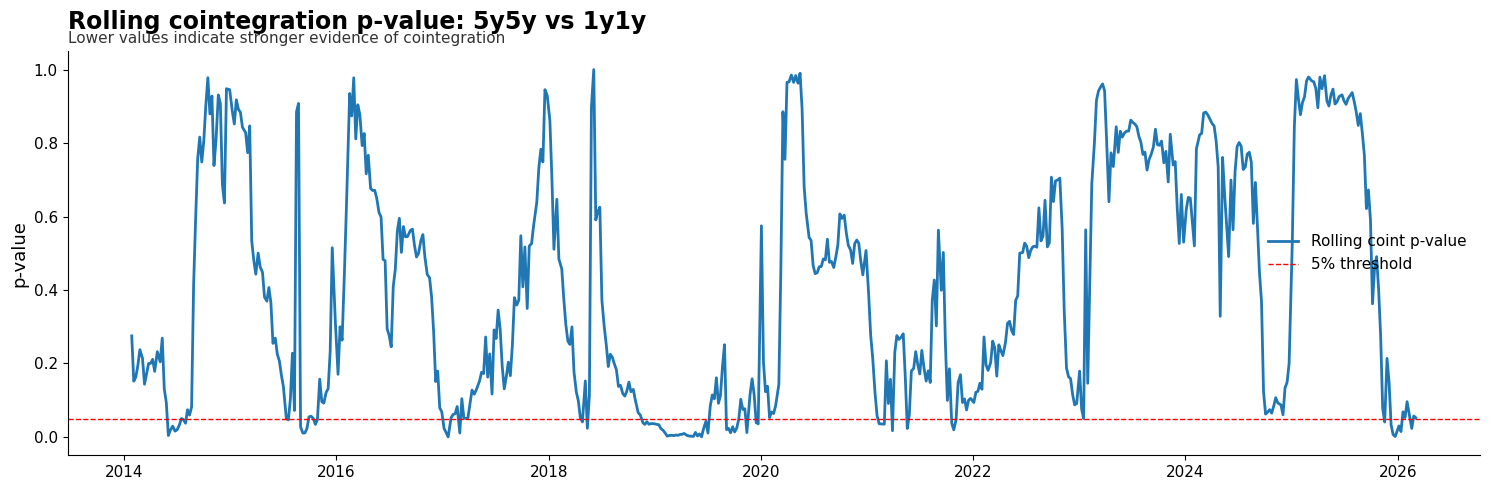

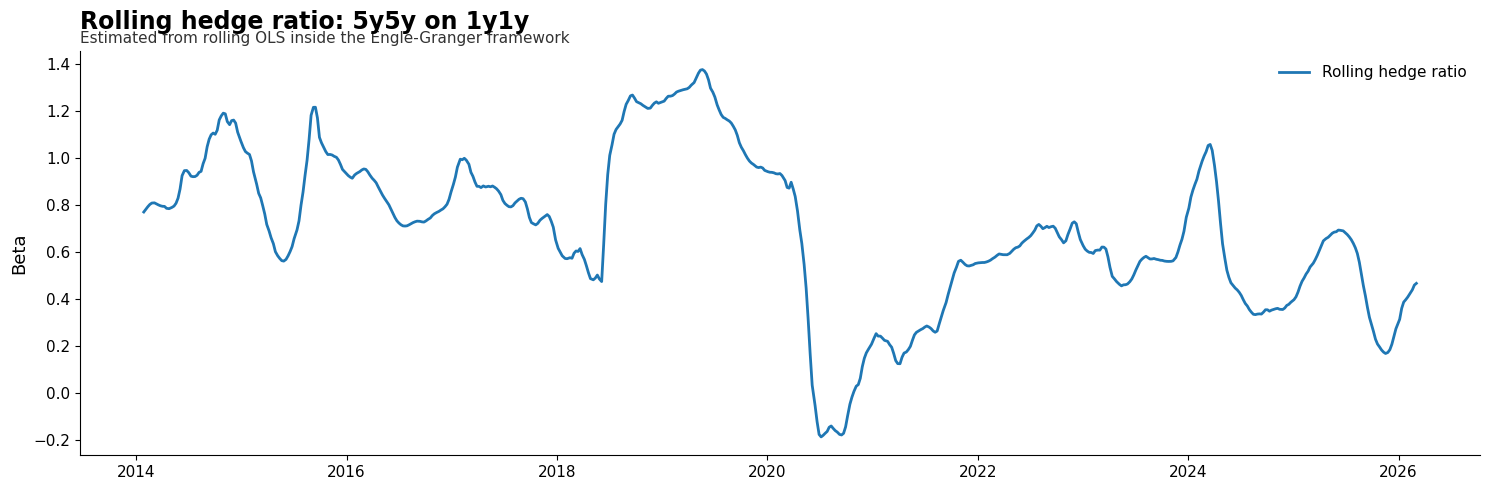

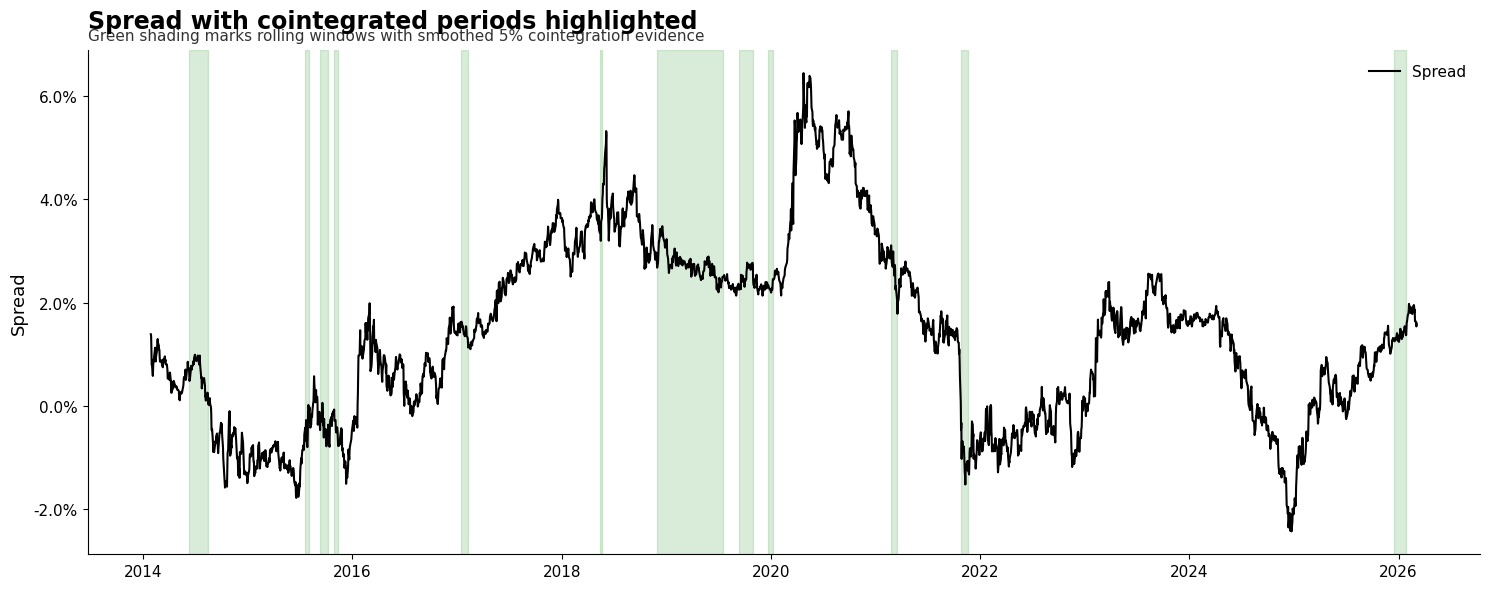

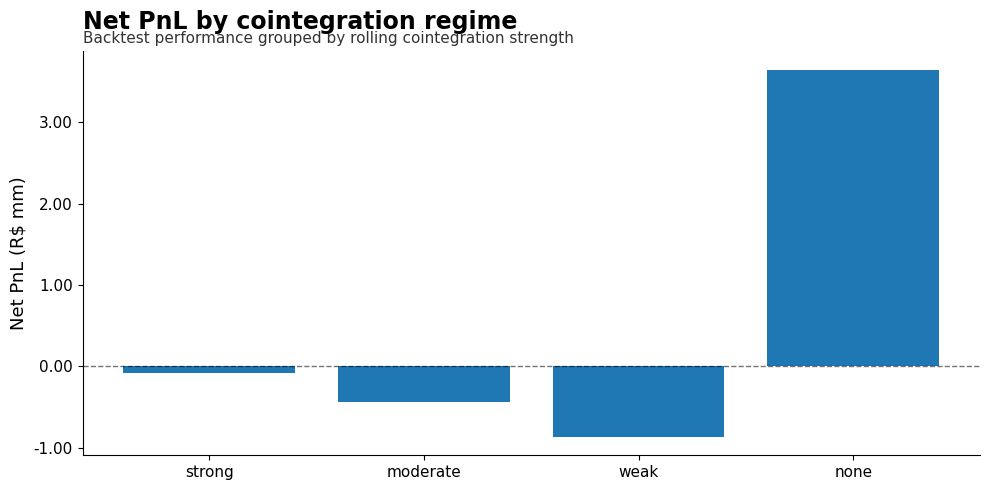

In [117]:
# ------------------------------------------------------------
# 10) Figures
# ------------------------------------------------------------

# 10.1 rolling cointegration p-value
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(coint_df["date"], coint_df["pvalue_coint"], label="Rolling coint p-value")
ax.axhline(0.05, color="red", linestyle="--", linewidth=1.0, label="5% threshold")

ax.set_title("Rolling cointegration p-value: 5y5y vs 1y1y", loc="left", pad=16, fontweight="bold")
add_subtitle(ax, "Lower values indicate stronger evidence of cointegration")
ax.set_ylabel("p-value")
setup_time_axis(ax)
ax.legend(frameon=False)

plt.tight_layout()
fig.savefig(COINT_FIG_DIR / "fig_23_rolling_cointegration_pvalue.png", bbox_inches="tight")
fig.savefig(COINT_FIG_DIR / "fig_23_rolling_cointegration_pvalue.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

# 10.2 hedge ratio / beta
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(coint_df["date"], coint_df["beta"], label="Rolling hedge ratio")

ax.set_title("Rolling hedge ratio: 5y5y on 1y1y", loc="left", pad=16, fontweight="bold")
add_subtitle(ax, "Estimated from rolling OLS inside the Engle-Granger framework")
ax.set_ylabel("Beta")
setup_time_axis(ax)
ax.legend(frameon=False)

plt.tight_layout()
fig.savefig(COINT_FIG_DIR / "fig_24_rolling_cointegration_beta.png", bbox_inches="tight")
fig.savefig(COINT_FIG_DIR / "fig_24_rolling_cointegration_beta.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

# 10.3 spread with shaded cointegrated periods
plot_df = df[["date", "spread_obs", "cointegrated_5pct_smooth"]].dropna().copy().reset_index(drop=True)

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(plot_df["date"], plot_df["spread_obs"], label="Spread", color="black", linewidth=1.5)

in_block = False
block_start = None

for i in range(len(plot_df)):
    flag = bool(plot_df["cointegrated_5pct_smooth"].iloc[i])

    if flag and not in_block:
        block_start = plot_df["date"].iloc[i]
        in_block = True
    elif not flag and in_block:
        block_end = plot_df["date"].iloc[i]
        ax.axvspan(block_start, block_end, color="green", alpha=0.15)
        in_block = False

if in_block:
    ax.axvspan(block_start, plot_df["date"].iloc[-1], color="green", alpha=0.15)

ax.set_title("Spread with cointegrated periods highlighted", loc="left", pad=16, fontweight="bold")
add_subtitle(ax, "Green shading marks rolling windows with smoothed 5% cointegration evidence")
ax.set_ylabel("Spread")
ax.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
setup_time_axis(ax)
ax.legend(frameon=False)

plt.tight_layout()
fig.savefig(COINT_FIG_DIR / "fig_25_spread_with_cointegrated_periods.png", bbox_inches="tight")
fig.savefig(COINT_FIG_DIR / "fig_25_spread_with_cointegrated_periods.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

# 10.4 net pnl by cointegration regime
if len(perf_by_regime) > 0:
    plot_perf = perf_by_regime.copy()
    plot_perf["total_pnl_mm"] = plot_perf["total_pnl"] / 1e6

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(plot_perf["cointegration_regime"], plot_perf["total_pnl_mm"])

    ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.55)
    ax.set_title("Net PnL by cointegration regime", loc="left", pad=16, fontweight="bold")
    add_subtitle(ax, "Backtest performance grouped by rolling cointegration strength")
    ax.set_ylabel("Net PnL (R$ mm)")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.2f}"))

    plt.tight_layout()
    fig.savefig(COINT_FIG_DIR / "fig_26_pnl_by_cointegration_regime.png", bbox_inches="tight")
    fig.savefig(COINT_FIG_DIR / "fig_26_pnl_by_cointegration_regime.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [118]:
# ------------------------------------------------------------
# 11) Save enriched dataset
# ------------------------------------------------------------
out_path = DATA_PROCESSED_DIR / "fair_value_zscore_with_cointegration.csv"
df.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: c:\Projetos\estudo_curva\data_processed\fair_value_zscore_with_cointegration.csv


In [119]:
print("\nSaved figure directory:", COINT_FIG_DIR)
print("Saved table directory:", TABLES_DIR)

print("\nKey artifacts generated:")
for name in [
    "tab_17_rolling_cointegration_summary",
    "tab_18_performance_by_cointegration_regime",
    "tab_19_cointegration_regime_spread_stats",
]:
    print("-", TABLES_DIR / f"{name}.csv")
    print("-", TABLES_DIR / f"{name}.tex")

for name in [
    "fig_23_rolling_cointegration_pvalue",
    "fig_24_rolling_cointegration_beta",
    "fig_25_spread_with_cointegrated_periods",
    "fig_26_pnl_by_cointegration_regime",
]:
    print("-", COINT_FIG_DIR / f"{name}.png")
    print("-", COINT_FIG_DIR / f"{name}.pdf")


Saved figure directory: c:\Projetos\estudo_curva\figures\05_cointegration
Saved table directory: c:\Projetos\estudo_curva\tables

Key artifacts generated:
- c:\Projetos\estudo_curva\tables\tab_17_rolling_cointegration_summary.csv
- c:\Projetos\estudo_curva\tables\tab_17_rolling_cointegration_summary.tex
- c:\Projetos\estudo_curva\tables\tab_18_performance_by_cointegration_regime.csv
- c:\Projetos\estudo_curva\tables\tab_18_performance_by_cointegration_regime.tex
- c:\Projetos\estudo_curva\tables\tab_19_cointegration_regime_spread_stats.csv
- c:\Projetos\estudo_curva\tables\tab_19_cointegration_regime_spread_stats.tex
- c:\Projetos\estudo_curva\figures\05_cointegration\fig_23_rolling_cointegration_pvalue.png
- c:\Projetos\estudo_curva\figures\05_cointegration\fig_23_rolling_cointegration_pvalue.pdf
- c:\Projetos\estudo_curva\figures\05_cointegration\fig_24_rolling_cointegration_beta.png
- c:\Projetos\estudo_curva\figures\05_cointegration\fig_24_rolling_cointegration_beta.pdf
- c:\Proje

In [124]:
import numpy as np
import pandas as pd

# residual da regressão cointegrante
df["coint_residual"] = df["fwd_5y5y"] - (df["alpha"] + df["beta"] * df["fwd_1y1y"])

# rolling z-score backward-looking
RESID_Z_WINDOW = 252

df["coint_resid_mean_roll"] = df["coint_residual"].rolling(RESID_Z_WINDOW).mean().shift(1)
df["coint_resid_std_roll"] = df["coint_residual"].rolling(RESID_Z_WINDOW).std().shift(1)

df["coint_residual_z"] = (
    (df["coint_residual"] - df["coint_resid_mean_roll"]) /
    df["coint_resid_std_roll"]
)

In [125]:
COINT_P_THRESHOLD = 0.05

df["is_cointegrated"] = df["pvalue_coint"] < COINT_P_THRESHOLD
df["is_cointegrated"] = df["is_cointegrated"].fillna(False)

In [126]:
df["is_cointegrated_smooth"] = (
    df["is_cointegrated"]
    .rolling(3, min_periods=1)
    .mean() >= 2/3
)

In [127]:
ENTRY_Z = 1.50
EXIT_Z = 0.50

def build_coint_position(z: pd.Series, is_coint: pd.Series, entry_z: float, exit_z: float) -> pd.Series:
    pos = []
    prev = 0.0

    for zval, coint_flag in zip(z, is_coint):
        if pd.isna(zval) or not bool(coint_flag):
            pos.append(0.0)
            prev = 0.0
            continue

        # mean reversion on cointegration residual
        if prev == 0.0:
            if zval >= entry_z:
                prev = -1.0   # residual high -> 5y5y rich -> short spread
            elif zval <= -entry_z:
                prev = 1.0    # residual low -> 5y5y cheap -> long spread
            else:
                prev = 0.0

        elif prev > 0.0:
            if zval >= entry_z:
                prev = -1.0
            elif zval >= -exit_z:
                prev = 0.0
            else:
                prev = 1.0

        elif prev < 0.0:
            if zval <= -entry_z:
                prev = 1.0
            elif zval <= exit_z:
                prev = 0.0
            else:
                prev = -1.0

        pos.append(prev)

    return pd.Series(pos, index=z.index)

df["position_coint"] = build_coint_position(
    df["coint_residual_z"],
    df["is_cointegrated"],
    entry_z=ENTRY_Z,
    exit_z=EXIT_Z
)

In [128]:
def build_hybrid_position(
    coint_z: pd.Series,
    is_coint: pd.Series,
    fair_z: pd.Series,
    entry_z: float,
    exit_z: float
) -> pd.Series:
    pos = []
    prev = 0.0

    for zc, coint_flag, zf in zip(coint_z, is_coint, fair_z):
        if bool(coint_flag) and pd.notna(zc):
            # mean reversion via cointegration residual
            zval = zc
            mode = "mr"
        elif pd.notna(zf):
            # fallback to fair value
            zval = zf
            mode = "fv"
        else:
            pos.append(0.0)
            prev = 0.0
            continue

        if prev == 0.0:
            if mode == "mr":
                if zval >= entry_z:
                    prev = -1.0
                elif zval <= -entry_z:
                    prev = 1.0
                else:
                    prev = 0.0
            else:
                if zval >= entry_z:
                    prev = 1.0
                elif zval <= -entry_z:
                    prev = -1.0
                else:
                    prev = 0.0

        elif prev > 0.0:
            if abs(zval) <= exit_z:
                prev = 0.0

        elif prev < 0.0:
            if abs(zval) <= exit_z:
                prev = 0.0

        pos.append(prev)

    return pd.Series(pos, index=coint_z.index)

df["position_hybrid"] = build_hybrid_position(
    coint_z=df["coint_residual_z"],
    is_coint=df["is_cointegrated"],
    fair_z=df["mispricing_z"],
    entry_z=ENTRY_Z,
    exit_z=EXIT_Z
)

In [130]:
DV01_POSITION = 10_000
TCOST_BPS = 0.50
ANNUALIZATION = 252

# conservadora
df["position_lag1_coint"] = df["position_coint"].shift(1).fillna(0.0)
df["gross_pnl_coint"] = df["position_lag1_coint"] * df["spread_change_1d_bps"] * DV01_POSITION
df["turnover_coint"] = df["position_coint"].diff().abs().fillna(0.0)
df["transaction_cost_coint"] = df["turnover_coint"] * TCOST_BPS * DV01_POSITION
df["net_pnl_coint"] = df["gross_pnl_coint"] - df["transaction_cost_coint"]
df["equity_net_coint"] = df["net_pnl_coint"].cumsum()
df["running_max_coint"] = df["equity_net_coint"].cummax()
df["drawdown_coint"] = df["equity_net_coint"] - df["running_max_coint"]

# híbrida
df["position_lag1_hybrid"] = df["position_hybrid"].shift(1).fillna(0.0)
df["gross_pnl_hybrid"] = df["position_lag1_hybrid"] * df["spread_change_1d_bps"] * DV01_POSITION
df["turnover_hybrid"] = df["position_hybrid"].diff().abs().fillna(0.0)
df["transaction_cost_hybrid"] = df["turnover_hybrid"] * TCOST_BPS * DV01_POSITION
df["net_pnl_hybrid"] = df["gross_pnl_hybrid"] - df["transaction_cost_hybrid"]
df["equity_net_hybrid"] = df["net_pnl_hybrid"].cumsum()
df["running_max_hybrid"] = df["equity_net_hybrid"].cummax()
df["drawdown_hybrid"] = df["equity_net_hybrid"] - df["running_max_hybrid"]

In [131]:
def compute_perf_metrics(backtest_df: pd.DataFrame, pnl_col: str, drawdown_col: str, position_col: str, turnover_col: str) -> dict:
    x = backtest_df[pnl_col].dropna().copy()

    if len(x) < 20:
        return {
            "nobs": len(x),
            "total_pnl": np.nan,
            "annualized_pnl": np.nan,
            "annualized_vol": np.nan,
            "sharpe": np.nan,
            "max_drawdown": np.nan,
            "avg_abs_position": np.nan,
            "annual_turnover": np.nan,
            "hit_ratio": np.nan,
        }

    mean_daily = x.mean()
    vol_daily = x.std()
    annualized_pnl = mean_daily * ANNUALIZATION
    annualized_vol = vol_daily * np.sqrt(ANNUALIZATION)
    sharpe = annualized_pnl / annualized_vol if annualized_vol > 0 else np.nan

    return {
        "nobs": len(x),
        "total_pnl": x.sum(),
        "annualized_pnl": annualized_pnl,
        "annualized_vol": annualized_vol,
        "sharpe": sharpe,
        "max_drawdown": backtest_df[drawdown_col].min(),
        "avg_abs_position": backtest_df[position_col].abs().mean(),
        "annual_turnover": backtest_df[turnover_col].sum() / (len(backtest_df) / ANNUALIZATION),
        "hit_ratio": (x > 0).mean(),
    }

comparison = pd.DataFrame([
    {"strategy": "fair_value_zscore", **compute_perf_metrics(df, "net_pnl", "drawdown", "position", "turnover")},
    {"strategy": "cointegration_only", **compute_perf_metrics(df, "net_pnl_coint", "drawdown_coint", "position_coint", "turnover_coint")},
    {"strategy": "hybrid_coint_fairvalue", **compute_perf_metrics(df, "net_pnl_hybrid", "drawdown_hybrid", "position_hybrid", "turnover_hybrid")},
])

print(comparison)

                 strategy  nobs     total_pnl  annualized_pnl  annualized_vol  \
0       fair_value_zscore  3252  2.250928e+06   174426.138695    1.694618e+06   
1      cointegration_only  3252  1.065954e+06    82601.623005    2.447522e+05   
2  hybrid_coint_fairvalue  3252  2.342949e+04     1815.569002    1.476442e+06   

     sharpe  max_drawdown  avg_abs_position  annual_turnover  hit_ratio  
0  0.102929 -4.240165e+06          0.581002         7.824162   0.292743  
1  0.337491 -5.809989e+05          0.019367         1.239471   0.011070  
2  0.001230 -4.810598e+06          0.418076         7.204427   0.209102  
